# Data exploration

## Explore silver database (silver_data.db) and show what data is present. Do we have tables or dataframes?

In [2]:
import sqlite3
import pandas as pd
from pathlib import Path                                                                                                                                                                                                                                                                     

silver_db_path = Path('../data/2_silver/silver_data.db')                                                                                                                                                                                                                                  
  
if not silver_db_path.exists():
    print(f"Silver database not found at: {silver_db_path}")
    print("Run data_loader_silver.py first to generate the silver database.")
else:
    conn_silver = sqlite3.connect(silver_db_path)
    cursor_silver = conn_silver.cursor()

# List all tables in the silver database
cursor_silver.execute("SELECT name FROM sqlite_master WHERE type='table';")
silver_tables = [row[0] for row in cursor_silver.fetchall()]

print(f"The silver database is a SQLite database — it stores data as tables (not dataframes).")
print(f"Dataframes are the in-memory pandas representation after loading a table.\n")
print(f"Found {len(silver_tables)} table(s) in silver_data.db:\n")

for table_name in silver_tables:
    cursor_silver.execute(f"SELECT COUNT(*) FROM [{table_name}]")
    n_rows = cursor_silver.fetchone()[0]
    cursor_silver.execute(f"PRAGMA table_info([{table_name}])")
    columns = [col[1] for col in cursor_silver.fetchall()]
    print(f"  Table : {table_name}")
    print(f"  Rows  : {n_rows}")
    print(f"  Cols  : {len(columns)}")
    print(f"  Fields: {columns}\n")

conn_silver.close()

The silver database is a SQLite database — it stores data as tables (not dataframes).
Dataframes are the in-memory pandas representation after loading a table.

Found 3 table(s) in silver_data.db:

  Table : 80072ned_silver
  Rows  : 5772
  Cols  : 13
  Fields: ['silver_id', 'bronze_pk', 'ID', 'BedrijfskenmerkenSBI2008', 'Perioden', 'Ziekteverzuimpercentage_1', '_source_file', 'BedrijfskenmerkenSBI2008_Title', 'BedrijfskenmerkenSBI2008_Description', 'BedrijfskenmerkenSBI2008_CategoryGroupID', 'Perioden_Title', 'Perioden_Description', 'Perioden_Status']

  Table : 83415NED_silver
  Rows  : 33
  Cols  : 107
  Fields: ['silver_id', 'bronze_pk', 'ID', 'Marges', 'Perioden', 'ZiekteverzuimVolgensWerknemers_1', 'ErgSnelWerken_2', 'ExtraHardWerken_3', 'HeelVeelWerkDoen_4', 'NietErgSnelWerken_5', 'NietExtraHardWerken_6', 'NietHeelVeelWerkDoen_7', 'RegelmatigVeelKrachtZetten_8', 'NietRegelmatigVeelKrachtZetten_9', 'RegelmatigHardPraten_10', 'RegelmatigTeMakenMetTrillingen_11', 'NietRegelmatigHar

## Can I load a table from silver_data.db into a dataframe (df), so I can use it for profiling?

In [3]:
import sqlite3
import pandas as pd
from pathlib import Path

silver_db_path = Path('../data/2_silver/silver_data.db')

# Load the 80072ned silver table into a dataframe
table_name = "80072ned_silver"

conn_silver = sqlite3.connect(silver_db_path)
df_silver = pd.read_sql_query(f"SELECT * FROM [{table_name}]", conn_silver)
conn_silver.close()

print(f"Loaded '{table_name}' into a dataframe.")
print(f"Shape : {df_silver.shape}  ({df_silver.shape[0]} rows × {df_silver.shape[1]} columns)")
print(f"Dtypes:\n{df_silver.dtypes}")
df_silver.head()

Loaded '80072ned_silver' into a dataframe.
Shape : (5772, 13)  (5772 rows × 13 columns)
Dtypes:
silver_id                                    int64
bronze_pk                                   object
ID                                          object
BedrijfskenmerkenSBI2008                    object
Perioden                                    object
Ziekteverzuimpercentage_1                   object
_source_file                                object
BedrijfskenmerkenSBI2008_Title              object
BedrijfskenmerkenSBI2008_Description        object
BedrijfskenmerkenSBI2008_CategoryGroupID    object
Perioden_Title                              object
Perioden_Description                        object
Perioden_Status                             object
dtype: object


,silver_id,bronze_pk,ID,BedrijfskenmerkenSBI2008,Perioden,Ziekteverzuimpercentage_1,_source_file,BedrijfskenmerkenSBI2008_Title,BedrijfskenmerkenSBI2008_Description,BedrijfskenmerkenSBI2008_CategoryGroupID,Perioden_Title,Perioden_Description,Perioden_Status
0,1,TypedDataSet.json_0,0,T001081,1996KW01,5.5,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten \r\nDeze categor...,1,1996 1e kwartaal,,Definitief
1,2,TypedDataSet.json_1,1,T001081,1996KW02,4.6,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten \r\nDeze categor...,1,1996 2e kwartaal,,Definitief
2,3,TypedDataSet.json_2,2,T001081,1996KW03,4.0,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten \r\nDeze categor...,1,1996 3e kwartaal,,Definitief
3,4,TypedDataSet.json_3,3,T001081,1996KW04,4.7,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten \r\nDeze categor...,1,1996 4e kwartaal,,Definitief
4,5,TypedDataSet.json_4,4,T001081,1996JJ00,4.7,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten \r\nDeze categor...,1,1996,,Definitief


## Use df_silver for exploration

In [4]:
import pandas as pd
import seaborn as sns
import missingno as msno
from ydata_profiling import ProfileReport
from pathlib import Path

# Quick insight in data quality
msno.matrix(df_silver)

# Genereer uitgebreid rapport voor je GitHub documentatie
profile = ProfileReport(df_silver, title="CBS Data Understanding Report")

output_path = Path(f"../output/understanding_{table_name}_report.html")
output_path.parent.mkdir(parents=True, exist_ok=True)
profile.to_file(output_path)

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 20.63it/s]


Grafiek succesvol opgeslagen in: ../output/missing_values_80072NED.png


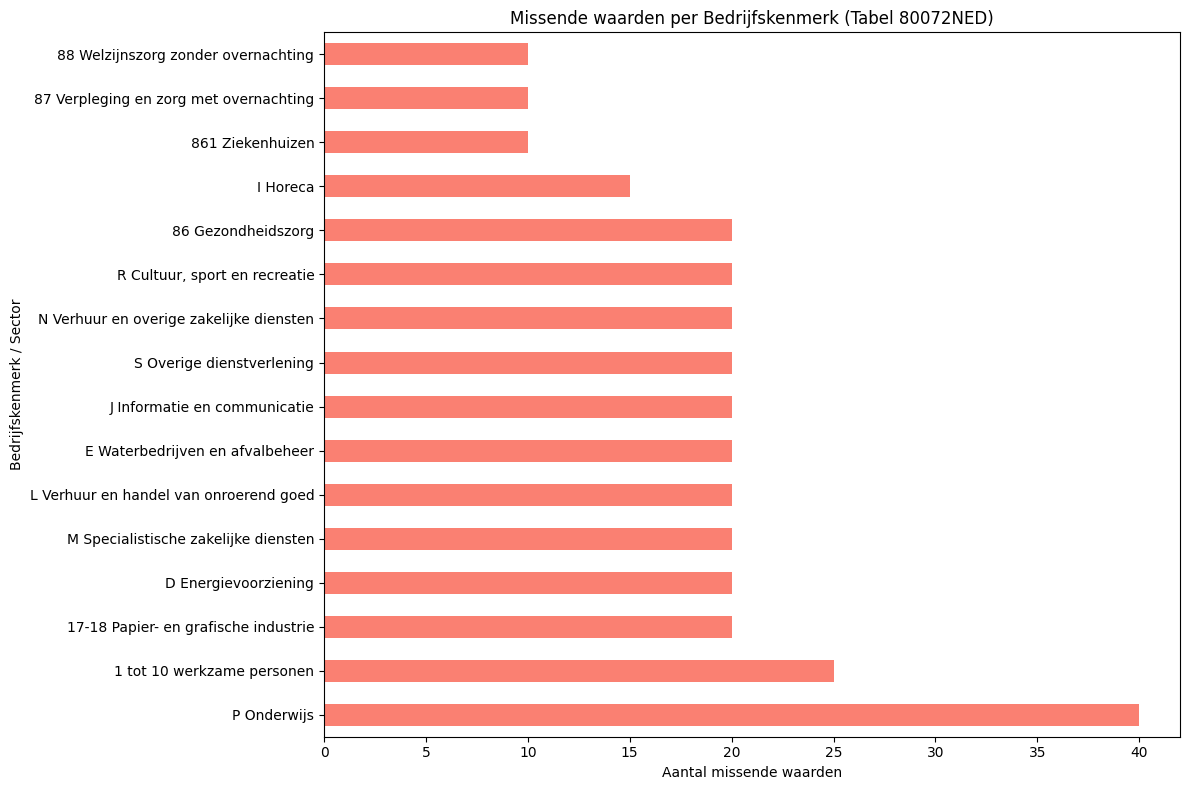

In [ ]:
import matplotlib.pyplot as plt
import os

# 1. Analyse uitvoeren
missing_analysis = df_silver[df_silver['Ziekteverzuimpercentage_1'].isnull()]['BedrijfskenmerkenSBI2008_Title'].value_counts()

# 2. De plot maken
plt.figure(figsize=(12, 8))
missing_analysis.plot(kind='barh', color='salmon')
plt.title('Missende waarden per Bedrijfskenmerk (Tabel 80072NED)')
plt.xlabel('Aantal missende waarden')
plt.ylabel('Bedrijfskenmerk / Sector')

# Zorg voor een nette layout zodat labels niet wegvallen
plt.tight_layout()

# 3. Exporteren naar de output map
output_path = '../output/missing_values_80072NED.png'

# Bonus: check of de map bestaat, anders aanmaken
os.makedirs(os.path.dirname(output_path), exist_ok=True)

plt.savefig(output_path, dpi=300) # dpi=300 zorgt voor een scherpe afbeelding voor in rapporten
print(f"Grafiek succesvol opgeslagen in: {output_path}")

plt.show() # Toon hem ook nog even in je VS Code notebook

## Backup code

### Which variables are numerical? And which are strings? How many variables do we have of both types? How many observations do we have? Suggestion: Split the original data in a data frame containing the numerical data and a data frame containing the string data.

**numerical data:**

The numerical type allows mathematical operations.

In [4]:
# Using Pandas.
df_pd_enriched_num    = enriched_fact.select_dtypes(include='number')

# Column names (Pandas: df_pd_orig_num.columns.tolist()).
l_df_num_names = df_pd_enriched_num.columns

print(f"We have {len(l_df_num_names)} numerical variables:\n{l_df_num_names}")

We have 4 numerical variables:
Index(['ID', 'Ziekteverzuimpercentage_1', 'CategoryGroupID', 'ID_category'], dtype='object')


In [5]:
# In Pandas.
df_pd_enriched_str    = enriched_fact.select_dtypes(include='object')

# Column names (Pandas: df_pd_orig_str.columns.tolist()).
l_df_str_names = df_pd_enriched_str.columns

print(f"We have {len(l_df_str_names)} string variables:\n{l_df_str_names}")

We have 12 string variables:
Index(['BedrijfskenmerkenSBI2008', 'Perioden', 'Title', 'Description',
       'Status', 'Key_bedrijfs', 'Title_bedrijfs', 'Description_bedrijfs',
       'DimensionKey', 'Title_category', 'Description_category', 'ParentID'],
      dtype='object')


Do we have all columns in both data frames? Yes, we do!

In [6]:
print(
    f"The original data has {enriched_fact.shape[1]} columns. The number and string data "
    f"have total of {df_pd_enriched_num.shape[1] + df_pd_enriched_str.shape[1]} columns."
)

The original data has 16 columns. The number and string data have total of 16 columns.


We observe 5772 observations (rows) in the data frame.

In [7]:
print(f"Number of observations: {enriched_fact.shape[0]}")

Number of observations: 5772


In [8]:
# We use the number of observations more often, so we define a variable.
n_enriched_obs = enriched_fact.shape[0]

### How many missing values do each of the variables have (variable completeness) and what are the variable types? Is `Ziekteverzuimpercentage_1` complete? And what other, missing-like values do you observe in the string data? Create a frequency table of missing data per variable.

**numerical data**:

Pandas' `describe()` function outputs some descriptive statistics. For numerical data these stats include: count of non-null values, mean, standard deviation, range (i.e., min and max), the lower quartile, the median, and the upper quartile. What can we conclude for the 'SalePrice' variable (min, max, median vs average)?

**numerical data:**

Not all numerical variables are complete. For example, `LotFrontage` has 490 missing values. All numerical variables are of type "int64".


In [9]:
# Pandas.
df_pd_missing_data_num = (
    
    pd.DataFrame({

        'data_type':    df_pd_enriched_num.dtypes,
        'missing':      df_pd_enriched_num.isnull().sum()   
    })

    # Add complete%
    .assign(
        complete_pct = lambda x: round(100 * (n_enriched_obs - x['missing']) / n_enriched_obs, 2)
    )

    # Remove variables that are complete.
    .query("complete_pct < 100")

    # Sort table by data completeness in descending order.
    .sort_values(by = 'complete_pct')
)

print(df_pd_missing_data_num)
print("")


                          data_type  missing  complete_pct
Ziekteverzuimpercentage_1   float64      310         94.63



**String data:**

Are all string variables are complete? Let's investigate the unique values. In case of Pandas we observe `nan` in addition to non-null data. 

In [19]:
# Pandas
print("Pandas:")

for name in l_df_str_names:
    print(f"{name}: {df_pd_enriched_str[name].unique()}")

Pandas:
BedrijfskenmerkenSBI2008: ['T001081' '301000' '305700' '300003' '307500' '307610' '317105' '320005'
 '328110' '346600' '348000' '350000' '300007' '354200' '354300' '356900'
 '371600' '383100' '383200' '389100' '391600' '396300' '402000' '403300'
 '410200' '415300' '300013' '417400' '419000' '422400' '422500' '422600'
 '425300' '426600' '428100' '435500' 'WP19078' 'WP19091' 'WP19098']
Perioden: ['1996KW01' '1996KW02' '1996KW03' '1996KW04' '1996JJ00' '1997KW01'
 '1997KW02' '1997KW03' '1997KW04' '1997JJ00' '1998KW01' '1998KW02'
 '1998KW03' '1998KW04' '1998JJ00' '1999KW01' '1999KW02' '1999KW03'
 '1999KW04' '1999JJ00' '2000KW01' '2000KW02' '2000KW03' '2000KW04'
 '2000JJ00' '2001KW01' '2001KW02' '2001KW03' '2001KW04' '2001JJ00'
 '2002KW01' '2002KW02' '2002KW03' '2002KW04' '2002JJ00' '2003KW01'
 '2003KW02' '2003KW03' '2003KW04' '2003JJ00' '2004KW01' '2004KW02'
 '2004KW03' '2004KW04' '2004JJ00' '2005KW01' '2005KW02' '2005KW03'
 '2005KW04' '2005JJ00' '2006KW01' '2006KW02' '2006KW03' '20

### Conduct descriptive/summary statistics for numerical variables (e.g., mean, median, std, and range) and for string variables (e.g., number of unique values, mode, and their frequency)

**numerical data**:

Pandas' `describe()` function outputs some descriptive statistics. For numerical data these stats include: count of non-null values, mean, standard deviation, range (i.e., min and max), the lower quartile, the median, and the upper quartile. What can we conclude for the 'SalePrice' variable (min, max, median vs average)?

In [20]:
df_pd_enriched_num.describe()

,ID,Ziekteverzuimpercentage_1,CategoryGroupID,ID_category
count,5772.000000,5462.000000,5772.000000,5772.000000
mean,2885.500000,4.580264,3.333333,3.333333
std,1666.377208,1.299420,0.857421,0.857421
min,0.000000,1.400000,1.000000,1.000000
25%,1442.750000,3.600000,3.000000,3.000000
50%,2885.500000,4.500000,3.000000,3.000000
75%,4328.250000,5.400000,4.000000,4.000000
max,5771.000000,10.100000,5.000000,5.000000


**String data:**

For string data, Pandas' `describe()` function includes: count of non-null values and unique values, value at high frequency ('top'), and its concerned frequency. 

In [21]:
df_pd_enriched_str.describe()


,BedrijfskenmerkenSBI2008,Perioden,Title,Description,Status,Key_bedrijfs,Title_bedrijfs,Description_bedrijfs,DimensionKey,Title_category,Description_category,ParentID
count,5772,5772,5772,5733,5772,5772,5772,5772,5772,5772,148,5772
unique,39,148,148,2,2,39,39,37,1,5,1,1
top,T001081,1996KW01,1996 1e kwartaal,,Definitief,T001081,A-U Alle economische activiteiten,"Het aantal ""werkzame personen"" bestaat uit: \r...",BedrijfskenmerkenSBI2008,Bedrijfstak,,0
freq,148,39,39,5616,5655,148,148,444,5772,2664,148,5772


### Save data to pickle file

We save objects - that we need in subsequent exercises - to a pickle file.

In [26]:
import os
import pickle

# Create dictionary 'dc_80072ned' with objects that will be used in the next exercises.
dc_uwv_80072ned = {
    'enriched_fact': enriched_fact,
    'l_df_num_names': l_df_num_names,
    'l_df_str_names': l_df_str_names,
}

# Ensure directory exists then save dc_uwv_80072ned as 'dc-uwv-80072ned.pkl'
out_dir = '../data/1_bronze'
os.makedirs(out_dir, exist_ok=True)
file_path = os.path.join(out_dir, 'dc-uwv-80072ned.pkl')

if os.path.exists(file_path):
    print(f"Overwriting existing file: {file_path}")
else:
    print(f"Saving to: {file_path}")

with open(file_path, 'wb') as pickle_file:
    pickle.dump(dc_uwv_80072ned, pickle_file, protocol=pickle.HIGHEST_PROTOCOL)

Saving to: ../data/1_bronze\dc-uwv-80072ned.pkl


### Explore silver database and show what data is present. Do we have tables or dataframes?

In [ ]:
import sqlite3
import pandas as pd
from pathlib import Path

silver_db_path = Path('../data/2_silver/silver_data.db')

if not silver_db_path.exists():
    print(f"Silver database not found at: {silver_db_path}")
    print("Run data_loader_silver.py first to generate the silver database.")
else:
    conn_silver = sqlite3.connect(silver_db_path)
    cursor_silver = conn_silver.cursor()

    # List all tables in the silver database
    cursor_silver.execute("SELECT name FROM sqlite_master WHERE type='table';")
    silver_tables = [row[0] for row in cursor_silver.fetchall()]

    print(f"The silver database is a SQLite database — it stores data as tables (not dataframes).")
    print(f"Dataframes are the in-memory pandas representation after loading a table.\n")
    print(f"Found {len(silver_tables)} table(s) in silver_data.db:\n")

    for table_name in silver_tables:
        cursor_silver.execute(f"SELECT COUNT(*) FROM [{table_name}]")
        n_rows = cursor_silver.fetchone()[0]
        cursor_silver.execute(f"PRAGMA table_info([{table_name}])")
        columns = [col[1] for col in cursor_silver.fetchall()]
        print(f"  Table : {table_name}")
        print(f"  Rows  : {n_rows}")
        print(f"  Cols  : {len(columns)}")
        print(f"  Fields: {columns}\n")

    conn_silver.close()